# Algorithmic Recourse

La idea es:
1. Crear un dataset sintético.
2. Entrenar un modelo interpretable.
3. Elegir un caso rechazado.
4. Definir qué variables son accionables y cuáles no.
5. Buscar cambios mínimos que cambien la predicción.
6. Explicar por qué esos cambios funcionan.
7. Extensiónes.

## 1. Importar librerías

In [1]:
# ============================================
# CELDA 1. IMPORTAR LIBRERÍAS
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from itertools import product
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report


In [2]:
#DATASET escogido Census income 

df_raw = pd.read_csv("../data/archive/adult.csv")
df_raw.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## 2. Data set
ajustamos en dataset para el procesamiento de los datos



In [3]:
#Limpieza de datos
df = df_raw[df_raw["workclass"]      != "?"].copy()
df = df[df["occupation"]             != "?"].copy()
df = df[df["native.country"]         != "?"].copy()
df = df.reset_index(drop=True)
#variable objetivo
df["income_bin"] = (df["income"].str.strip() == ">50K").astype(int)

#Visualización
print(f"Filas totales después de limpieza: {len(df):,}")
print()
print("Distribución de la variable objetivo:")
print(df["income_bin"].value_counts(normalize=True).rename({0: "<=50K (0)", 1: ">50K (1)"}))
print()
print("Primeras filas del dataset limpio:")
display(df[["age", "education", "education.num", "hours.per.week",
            "capital.gain", "capital.loss", "income_bin"]].head(8))

Filas totales después de limpieza: 30,162

Distribución de la variable objetivo:
income_bin
<=50K (0)    0.751078
>50K (1)     0.248922
Name: proportion, dtype: float64

Primeras filas del dataset limpio:


,age,education,education.num,hours.per.week,capital.gain,capital.loss,income_bin
0,82,HS-grad,9,18,0,4356,0
1,54,7th-8th,4,40,0,3900,0
2,41,Some-college,10,40,0,3900,0
3,34,HS-grad,9,45,0,3770,0
4,38,10th,6,40,0,3770,0
5,74,Doctorate,16,20,0,3683,1
6,68,HS-grad,9,40,0,3683,0
7,45,Doctorate,16,35,0,3004,1


age: Inmutable, (no disminuye) Edad en años 

education.num:  Accionable,  Nivel educativo en escala 1–16 

hours.per.week:  Accionable,  Horas trabajadas por semana 

capital.gain:  Accionable,  Ganancias de capital (USD)
 
Capital.loss:  Accionable,  Pérdidas de capital (USD) 

## 3. Entrenar un modelo interpretable

Usaremos **regresión logística** porque es una buena puerta de entrada para entender recourse.


In [4]:
feature_names = [
    "age",
    "education.num",
    "hours.per.week",
    "capital.gain",
    "capital.loss"
]

X = df[feature_names]
y = df["income_bin"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

test_proba = model.predict_proba(X_test)[:, 1]
test_pred  = (test_proba >= 0.5).astype(int)

print(f"Tamaño train: {len(X_train):,}  |  Tamaño test: {len(X_test):,}")
print()
print("AUC en test:", round(roc_auc_score(y_test, test_proba), 3))
print()
print("Reporte de clasificación:")
print(classification_report(y_test, test_pred, target_names=["<=50K", ">50K"]))


Tamaño train: 22,621  |  Tamaño test: 7,541

AUC en test: 0.839

Reporte de clasificación:
              precision    recall  f1-score   support

       <=50K       0.83      0.95      0.89      5664
        >50K       0.74      0.40      0.52      1877

    accuracy                           0.82      7541
   macro avg       0.78      0.68      0.70      7541
weighted avg       0.81      0.82      0.79      7541



## 4. Interpretar el modelo

Aquí miramos qué variables empujan hacia la aprobación y cuáles hacia el rechazo.


In [5]:
coef_df = pd.DataFrame({
    "feature":     feature_names,
    "coefficient": model.coef_[0]
}).sort_values("coefficient", ascending=False)

print("Coeficientes del modelo (ordenados de mayor a menor):")
display(coef_df)

# ── Pasos significativos por variable ───────────────────────────────────────
# Representan un cambio mínimo realista que una persona podría hacer
meaningful_steps = {
    "age":            1,      # 1 año más (inmutable: no decrece)
    "education.num":  1,      # subir un nivel educativo
    "hours.per.week": 5,      # 5 horas más por semana
    "capital.gain":   500,    # 500 USD más de ganancia de capital
    "capital.loss":   500     # 500 USD más de pérdida (sube el coef negativo)
}

rows = []
for f, beta in zip(feature_names, model.coef_[0]):
    step = meaningful_steps[f]
    odds_multiplier = np.exp(beta * step)
    rows.append({
        "feature":                f,
        "step_used":              step,
        "beta":                   round(beta, 4),
        "odds_multiplier_for_step": round(odds_multiplier, 4)
    })

interpret_df = pd.DataFrame(rows).sort_values("beta", ascending=False)
print()
print("Impacto de un paso significativo por variable:")
display(interpret_df)

print()
print("Lectura rápida:")
print("- Coeficiente POSITIVO → subir esa variable AUMENTA la probabilidad de ganar >50K.")
print("- Coeficiente NEGATIVO → subir esa variable REDUCE la probabilidad de ganar >50K.")
print("- odds_multiplier > 1  → el paso multiplica los odds a favor de >50K.")
print("- odds_multiplier < 1  → el paso reduce los odds a favor de >50K.")


Coeficientes del modelo (ordenados de mayor a menor):


,feature,coefficient
1,education.num,0.313728
0,age,0.043114
2,hours.per.week,0.038951
4,capital.loss,0.000680
3,capital.gain,0.000325



Impacto de un paso significativo por variable:


,feature,step_used,beta,odds_multiplier_for_step
1,education.num,1,0.3137,1.3685
0,age,1,0.0431,1.0441
2,hours.per.week,5,0.0390,1.2150
4,capital.loss,500,0.0007,1.4046
3,capital.gain,500,0.0003,1.1766



Lectura rápida:
- Coeficiente POSITIVO → subir esa variable AUMENTA la probabilidad de ganar >50K.
- Coeficiente NEGATIVO → subir esa variable REDUCE la probabilidad de ganar >50K.
- odds_multiplier > 1  → el paso multiplica los odds a favor de >50K.
- odds_multiplier < 1  → el paso reduce los odds a favor de >50K.


### Interpretación de los coeficientes

- education.num tiene el coeficiente más alto: cada nivel educativo adicional multiplica los odds de ganar >50K por un factor considerable. Es la variable más poderosa y accionable.
- hours.per.week y age también contribuyen positivamente, aunque con menor magnitud.
- capital.gain tiene coeficiente positivo pequeño pero puede tener efecto si el valor es muy alto.
- capital.loss tiene coeficiente positivo pequeño también (en este modelo, capital loss tiene correlación con actividad de inversión).

## 5. Elegir un caso rechazado para hacer recourse

In [6]:
test_results = X_test.copy()
test_results["true_label"] = y_test.values
test_results["pred_prob"]  = test_proba
test_results["pred_label"] = test_pred

rejected = (
    test_results[test_results["pred_label"] == 0]
    .sort_values("pred_prob", ascending=False)
)

print("Casos rechazados más cercanos al umbral de decisión (prob más alta):")
display(rejected.head(10))

# Seleccionamos el índice 6 (igual que el notebook original, pero sobre este dataset)
person_index = rejected.index[6]
person        = rejected.loc[person_index, feature_names].copy()

print(f"\n─── Perfil seleccionado (índice {person_index}) ───")
display(person.to_frame(name="valor_actual"))

current_prob = model.predict_proba(pd.DataFrame([person]))[0, 1]
print(f"\nProbabilidad actual de ganar >50K : {current_prob:.4f}")
print(f"Predicción actual                  : {'RECHAZADO (<=50K)' if current_prob < 0.5 else 'APROBADO (>50K)'}")
print()
print("Esta persona está muy cerca del umbral. Con cambios pequeños en variables")
print("accionables (educación, horas trabajadas) podría cruzar al lado positivo.")


Casos rechazados más cercanos al umbral de decisión (prob más alta):


,age,education.num,hours.per.week,capital.gain,capital.loss,true_label,pred_prob,pred_label
108,49,9,40,0,2377,1,0.499427,0
23359,32,14,60,0,0,1,0.499314,0
5628,51,13,47,0,0,1,0.499080,0
17642,50,14,40,0,0,1,0.498569,0
17107,50,14,40,0,0,0,0.498569,0
9585,61,10,60,0,0,1,0.498161,0
2575,24,10,40,7298,0,1,0.498103,0
3693,68,9,40,2414,0,0,0.496737,0
12708,29,15,55,0,0,0,0.496721,0
19532,39,13,60,0,0,0,0.496331,0



─── Perfil seleccionado (índice 2575) ───


,valor_actual
age,24
education.num,10
hours.per.week,40
capital.gain,7298
capital.loss,0



Probabilidad actual de ganar >50K : 0.4981
Predicción actual                  : RECHAZADO (<=50K)

Esta persona está muy cerca del umbral. Con cambios pequeños en variables
accionables (educación, horas trabajadas) podría cruzar al lado positivo.


## 6. Definir acción, restricciones y costo

Esta es la médula del recourse: no todo se puede cambiar, no todo cambia en cualquier dirección y no todo cuesta lo mismo.


In [7]:
# ============================================
# CELDA 6. DEFINIR REGLAS DE ACTIONABILITY
# ============================================

feature_labels = {
    "age": "Edad",
    "education.num": "Nivel educativo",
    "hours.per.week": "Horas trabajadas por semana",
    "capital.gain": "Ganancias de capital",
    "capital.loss": "Pérdidas de capital"
}

coef_map = dict(zip(feature_names, model.coef_[0]))

# Regla general:
# - age: inmutable
# - education.num: accionable, solo aumenta
# - hours.per.week: accionable, solo aumenta
# - capital.gain: accionable, solo aumenta
# - capital.loss: en versión base se deja fuera por menor interpretabilidad;
#   en versión extendida se puede activar si ayuda a cruzar el umbral.

immutable_features = ["age"]

gain_q99 = float(np.ceil(df["capital.gain"].quantile(0.99) / 500) * 500)
loss_q99 = float(np.ceil(df["capital.loss"].quantile(0.99) / 500) * 500)

# Etapa 1: reglas más realistas
actionable_features_core = {
    "education.num": {
        "direction": "increase",
        "step": 1,
        "max_change": 6,
        "min_value": int(df["education.num"].min()),
        "max_value": int(df["education.num"].max()),
        "unit_cost": 3.0,
        "justification": "Aumentar nivel educativo requiere tiempo/esfuerzo"
    },
    "hours.per.week": {
        "direction": "increase",
        "step": 5,
        "max_change": 30,
        "min_value": int(df["hours.per.week"].min()),
        "max_value": min(80, int(df["hours.per.week"].max())),
        "unit_cost": 1.0,
        "justification": "Trabajar más horas es accionable, pero con costo moderado"
    },
    "capital.gain": {
        "direction": "increase",
        "step": 500,
        "max_change": max(5000, gain_q99),
        "min_value": int(df["capital.gain"].min()),
        "max_value": int(max(gain_q99, df["capital.gain"].max())),
        "unit_cost": 2.0,
        "justification": "Puede aumentar, pero no siempre es fácil ni inmediato"
    }
}

# Etapa 2: búsqueda extendida
# Si capital.loss tiene coeficiente positivo, subirla ayuda al modelo,
# aunque como recomendación humana es menos intuitiva. Se deja como plan B.
actionable_features_extended = dict(actionable_features_core)

if coef_map.get("capital.loss", 0) > 0:
    actionable_features_extended["capital.loss"] = {
        "direction": "increase",
        "step": 500,
        "max_change": max(3000, loss_q99),
        "min_value": int(df["capital.loss"].min()),
        "max_value": int(max(loss_q99, df["capital.loss"].max())),
        "unit_cost": 4.0,
        "justification": "Solo en búsqueda extendida: útil para el modelo, menos interpretable"
    }

# Se deja esta variable para compatibilidad con celdas posteriores del notebook.
actionable_features = actionable_features_core

rules_rows = []
for f, cfg in actionable_features_core.items():
    rules_rows.append({
        "feature": f,
        "nombre": feature_labels.get(f, f),
        "valor_actual": float(person[f]),
        "direction": cfg["direction"],
        "step": cfg["step"],
        "max_change": cfg["max_change"],
        "min_value": cfg["min_value"],
        "max_value": cfg["max_value"],
        "unit_cost": cfg["unit_cost"],
        "modo": "core",
        "justificación": cfg["justification"]
    })

for f, cfg in actionable_features_extended.items():
    if f not in actionable_features_core:
        rules_rows.append({
            "feature": f,
            "nombre": feature_labels.get(f, f),
            "valor_actual": float(person[f]),
            "direction": cfg["direction"],
            "step": cfg["step"],
            "max_change": cfg["max_change"],
            "min_value": cfg["min_value"],
            "max_value": cfg["max_value"],
            "unit_cost": cfg["unit_cost"],
            "modo": "extendido",
            "justificación": cfg["justification"]
        })

rules_df = pd.DataFrame(rules_rows)

print("Variables inmutables:", immutable_features)
print("\nReglas de actionability:")
display(rules_df)


Variables inmutables: ['age', 'dependents']

Variables accionables:
education_years -> {'direction': 'increase', 'step': 1, 'max_change': 4, 'min_value': 9, 'max_value': 20, 'unit_cost': 1.0}
income_k -> {'direction': 'increase', 'step': 5, 'max_change': 40, 'min_value': 10, 'max_value': 100, 'unit_cost': 1.0}
savings_k -> {'direction': 'increase', 'step': 5, 'max_change': 30, 'min_value': 0, 'max_value': 80, 'unit_cost': 0.8}
debt_ratio -> {'direction': 'decrease', 'step': 0.05, 'max_change': 0.3, 'min_value': 0.0, 'max_value': 0.95, 'unit_cost': 1.5}
late_payments -> {'direction': 'decrease', 'step': 1, 'max_change': 3, 'min_value': 0, 'max_value': 8, 'unit_cost': 1.2}


## Definición de reglas de *actionability*

En esta sección se fija el marco metodológico del *recourse*: **qué se puede cambiar, en qué dirección, con qué granularidad y con qué costo**. El punto clave es que una recomendación no debe ser solamente eficaz para el modelo, sino también razonable desde el punto de vista humano e interpretable para quien la lee.

### Variables inmutables

La variable `age` se considera **inmutable**. Puede influir en la predicción, pero no es admisible que el sistema la use como palanca de intervención. Por eso se excluye del espacio de búsqueda.

### Variables accionables principales

La búsqueda base (`core`) permite modificar solo variables con una interpretación relativamente clara:

- `education.num`: solo puede **aumentar**, porque un mayor nivel educativo puede mejorar la probabilidad predicha y no tendría sentido recomendar una disminución.
- `hours.per.week`: solo puede **aumentar**, bajo la idea de mayor dedicación laboral.
- `capital.gain`: solo puede **aumentar**, como una proxy de mejora económica.

Para cada variable se define:

- **`direction`**: dirección admisible del cambio.
- **`step`**: tamaño mínimo del cambio evaluado por la búsqueda.
- **`max_change`**: límite máximo respecto al valor original.
- **`min_value` / `max_value`**: cotas válidas observadas en los datos.
- **`unit_cost`**: costo por unidad de cambio, usado para priorizar recomendaciones más plausibles.

### Búsqueda extendida

Además se define una versión `extended` del conjunto de reglas. Si el coeficiente de `capital.loss` en la regresión logística resulta positivo, se habilita esta variable como apoyo en una segunda etapa de búsqueda. Esto no implica que sea la recomendación más intuitiva desde el punto de vista humano; solo significa que el modelo la está utilizando como señal favorable y, por tanto, puede servir para obtener un primer recourse factible sin modificar las celdas 2–5.

### Costo e interpretabilidad

La construcción del costo refleja que no todos los cambios son igual de fáciles:

- subir el nivel educativo tiene un costo alto;
- aumentar horas de trabajo tiene un costo moderado;
- aumentar `capital.gain` tiene un costo intermedio;
- `capital.loss`, cuando aparece en modo extendido, recibe una penalización mayor por ser menos interpretable.

Con esto, la salida no solo buscará cambios que crucen el umbral del modelo, sino que preferirá alternativas **más escasas, más baratas y más comprensibles**.


## 7. Buscar recourse por fuerza bruta explicable

La estrategia aquí es deliberadamente docente: búsqueda por grilla. No es la más elegante para producción, pero sí una de las más transparentes.


In [8]:
# ============================================
# CELDA 7. FUNCIONES DE RECOURSE
# ============================================

def build_candidate_values(current_value, cfg):
    step = cfg["step"]
    max_change = cfg["max_change"]

    if cfg["direction"] == "increase":
        upper = min(current_value + max_change, cfg["max_value"])
        values = np.arange(current_value, upper + 1e-9, step)
    elif cfg["direction"] == "decrease":
        lower = max(current_value - max_change, cfg["min_value"])
        values = np.arange(lower, current_value + 1e-9, step)
    else:
        raise ValueError(f"Dirección no soportada: {cfg['direction']}")

    values = np.round(values, 6)
    return sorted(set(values))


def recourse_cost(original, candidate, actionable_features, sparsity_weight=0.5):
    total = 0.0
    detail = {}
    changed_features = []

    for f, cfg in actionable_features.items():
        delta = float(candidate[f] - original[f])

        if abs(delta) < 1e-9:
            detail[f] = 0.0
            continue

        if cfg["direction"] == "increase" and delta < 0:
            return np.inf, {}, []
        if cfg["direction"] == "decrease" and delta > 0:
            return np.inf, {}, []

        steps_used = abs(delta) / cfg["step"]
        feature_cost = steps_used * cfg["unit_cost"]

        detail[f] = round(feature_cost, 4)
        total += feature_cost
        changed_features.append(f)

    sparsity_penalty = sparsity_weight * len(changed_features)
    detail["sparsity_penalty"] = round(sparsity_penalty, 4)
    total += sparsity_penalty

    return round(total, 4), detail, changed_features


def find_recourse(person_row, model, feature_names, actionable_features, threshold=0.50):
    value_grid = {
        f: build_candidate_values(float(person_row[f]), cfg)
        for f, cfg in actionable_features.items()
    }

    candidates = []
    best_partial = None

    for values in product(*[value_grid[f] for f in actionable_features.keys()]):
        candidate = person_row.copy()

        for f, v in zip(actionable_features.keys(), values):
            candidate[f] = v

        x_candidate = pd.DataFrame([candidate[feature_names]])
        prob = float(model.predict_proba(x_candidate)[0, 1])

        total_cost, cost_detail, changed_features = recourse_cost(
            original=person_row,
            candidate=candidate,
            actionable_features=actionable_features,
            sparsity_weight=0.5
        )

        info = {
            "prob_approve": round(prob, 4),
            "total_cost": total_cost,
            "candidate": candidate.copy(),
            "cost_detail": cost_detail,
            "n_changed_features": len(changed_features),
            "changed_features": changed_features
        }

        if (best_partial is None) or (prob > best_partial["prob_approve"]):
            best_partial = info

        if prob >= threshold:
            candidates.append(info)

    if len(candidates) == 0:
        return None, [], best_partial

    candidates = sorted(
        candidates,
        key=lambda x: (x["total_cost"], x["n_changed_features"], -x["prob_approve"])
    )

    return candidates[0], candidates, best_partial


# Probabilidad actual del caso seleccionado en la celda 5
current_prob = float(model.predict_proba(pd.DataFrame([person[feature_names]]))[0, 1])
print(f"Probabilidad actual del caso seleccionado: {current_prob:.4f}")

# Etapa 1: búsqueda core
best_recourse, all_candidates, best_partial = find_recourse(
    person_row=person,
    model=model,
    feature_names=feature_names,
    actionable_features=actionable_features_core,
    threshold=0.50
)

search_mode = "core"
actionable_features = actionable_features_core

# Etapa 2: si no alcanza, ampliar sin tocar celdas 2–5
if best_recourse is None:
    best_recourse, all_candidates, best_partial = find_recourse(
        person_row=person,
        model=model,
        feature_names=feature_names,
        actionable_features=actionable_features_extended,
        threshold=0.50
    )
    search_mode = "extendido"
    actionable_features = actionable_features_extended

print(f"\nModo de búsqueda usado: {search_mode}")
print("Número de soluciones de recourse encontradas:", len(all_candidates))

if best_recourse is None:
    print("\nNo se encontró recourse que cruce el umbral de 0.50.")
    print("Mejor candidato parcial encontrado:")
    print({
        "prob_approve": best_partial["prob_approve"],
        "total_cost": best_partial["total_cost"],
        "changed_features": best_partial["changed_features"]
    })
else:
    print("\nMejor solución encontrada:")
    print({
        "prob_approve": best_recourse["prob_approve"],
        "total_cost": best_recourse["total_cost"],
        "n_changed_features": best_recourse["n_changed_features"],
        "changed_features": best_recourse["changed_features"],
        "cost_detail": best_recourse["cost_detail"]
    })


KeyError: 'education_years'

## Funciones de *recourse* y lectura de los resultados

En esta sección se implementa el motor manual de recourse mediante una **búsqueda por fuerza bruta explicable**. La idea no es optimizar computacionalmente el problema, sino mostrar con transparencia cómo se construyen y evalúan las alternativas.

### Lógica general del procedimiento

1. Para cada variable accionable, se genera una grilla de valores permitidos según sus restricciones.
2. Luego se forman todas las combinaciones posibles entre esos valores.
3. Cada combinación se evalúa con el modelo entrenado.
4. Se calcula su costo total.
5. Se conservan las soluciones que superan el umbral de aprobación.
6. Si ninguna lo supera, se conserva al menos el mejor candidato parcial para que el notebook siga siendo interpretable.

### `build_candidate_values`

Esta función construye el conjunto de valores factibles para una variable concreta a partir de cuatro ideas: dirección permitida, tamaño del paso, máximo cambio admisible y límites globales. Así se evita explorar recomendaciones imposibles o arbitrarias.

### `recourse_cost`

La función de costo suma dos componentes:

- **costo por magnitud de cambio**, calculado a partir del número de pasos realizados y del `unit_cost` de cada variable;
- **penalización por esparsidad**, que castiga cambiar demasiadas variables al mismo tiempo.

Con ello se favorecen recomendaciones más económicas y más simples de comunicar.

### `find_recourse`

Esta es la función principal. Recorre todas las combinaciones factibles, calcula su probabilidad de aprobación y ordena las soluciones usando tres criterios:

1. menor costo total;
2. menor número de variables modificadas;
3. mayor probabilidad predicha.

Además, la búsqueda se realiza en dos etapas:

- **modo `core`**: usa solo variables más interpretables;
- **modo `extendido`**: amplía el espacio de búsqueda si el modo base no encuentra una solución que cruce el umbral.

Ese diseño permite cumplir con dos objetivos a la vez: mantener el recourse razonable y, al mismo tiempo, asegurar que el notebook produzca un resultado útil sin alterar las celdas 2–5.


## 8. Mostrar el recourse de forma interpretable

In [ ]:
# ============================================
# CELDA 8. RESUMEN HUMANO DEL RECOURSE
# ============================================

def human_change_text(feature, old, new):
    label = feature_labels.get(feature, feature)
    delta = float(new - old)

    if abs(delta) < 1e-9:
        return None

    if delta > 0:
        return f"{label}: subir de {old} a {new} (+{round(delta, 3)})"
    else:
        return f"{label}: bajar de {old} a {new} ({round(delta, 3)})"


if best_recourse is None:
    candidate = best_partial["candidate"]

    summary_rows = []
    for f in feature_names:
        summary_rows.append({
            "feature": f,
            "nombre": feature_labels.get(f, f),
            "original": float(person[f]),
            "recommended": float(candidate[f]),
            "delta": round(float(candidate[f] - person[f]), 4)
        })

    summary_df = pd.DataFrame(summary_rows)
    changed_df = summary_df[summary_df["delta"] != 0].copy()

    print("No se encontró recourse completo bajo las reglas actuales.")
    print("Sin embargo, este fue el mejor cambio parcial encontrado:")
    display(changed_df if len(changed_df) > 0 else summary_df)

    print("\nProbabilidad original:",
          round(float(model.predict_proba(pd.DataFrame([person[feature_names]]))[0, 1]), 4))
    print("Mejor probabilidad alcanzada:",
          round(float(model.predict_proba(pd.DataFrame([candidate[feature_names]]))[0, 1]), 4))
    print("Costo total:", best_partial["total_cost"])

    changes_text = []
    for f in feature_names:
        txt = human_change_text(f, person[f], candidate[f])
        if txt is not None:
            changes_text.append(txt)

    if len(changes_text) > 0:
        print("\nInterpretación simple:")
        print("Para acercar el caso al lado positivo del modelo, los cambios más útiles fueron:")
        for t in changes_text:
            print("-", t)

else:
    candidate = best_recourse["candidate"]

    summary_rows = []
    for f in feature_names:
        summary_rows.append({
            "feature": f,
            "nombre": feature_labels.get(f, f),
            "original": float(person[f]),
            "recommended": float(candidate[f]),
            "delta": round(float(candidate[f] - person[f]), 4)
        })

    summary_df = pd.DataFrame(summary_rows)
    changed_df = summary_df[summary_df["delta"] != 0].copy()

    print("Recourse encontrado correctamente.")
    print(f"Modo de búsqueda: {search_mode}")
    print()

    print("Tabla completa del antes y después:")
    display(summary_df)

    print("Variables que realmente cambiaron:")
    display(changed_df)

    original_prob = float(model.predict_proba(pd.DataFrame([person[feature_names]]))[0, 1])
    new_prob = float(model.predict_proba(pd.DataFrame([candidate[feature_names]]))[0, 1])

    print("Probabilidad original:", round(original_prob, 4))
    print("Probabilidad con recourse:", round(new_prob, 4))
    print("Costo total:", best_recourse["total_cost"])
    print("Detalle del costo:", best_recourse["cost_detail"])

    changes_text = []
    for f in feature_names:
        txt = human_change_text(f, person[f], candidate[f])
        if txt is not None:
            changes_text.append(txt)

    print("\nResumen simple del recourse:")
    print("El modelo inicialmente rechazaba este caso, pero encontró una combinación de cambios accionables")
    print("que lo lleva por encima del umbral de decisión.")
    print()

    print("Cambios recomendados:")
    for t in changes_text:
        print("-", t)

    print()
    print("Interpretación:")
    print("El recourse funciona porque aumenta variables con contribución positiva al modelo")
    print("sin modificar atributos inmutables como la edad.")


,feature,original,recommended,delta
0,age,43.000,43.000,0.000
1,education_years,10.000,10.000,0.000
2,income_k,47.400,47.400,0.000
3,savings_k,28.300,33.300,5.000
4,debt_ratio,0.090,0.050,-0.040
5,late_payments,0.000,0.000,0.000
6,dependents,1.000,1.000,0.000


Probabilidad original: 0.4347
Probabilidad con recourse: 0.6313
Costo total: 2.0
Detalle del costo: {'education_years': np.float64(0.0), 'income_k': np.float64(0.0), 'savings_k': np.float64(0.8), 'debt_ratio': np.float64(1.2), 'late_payments': np.float64(0.0)}


## Resumen simple del *recourse* e interpretación de los resultados

La salida de esta sección traduce el resultado del motor de búsqueda a un formato entendible para una persona. El objetivo no es solo informar si se halló o no una solución, sino mostrar **qué cambió, cuánto cambió, cuánto cuesta y cómo se altera la probabilidad predicha**.

### Si existe recourse completo

Cuando el algoritmo encuentra una solución que supera el umbral de decisión, se presentan dos tablas:

- una tabla completa con el antes y el después de todas las variables del caso;
- una tabla reducida con solo las variables que realmente cambiaron.

Después se reportan cuatro elementos clave:

1. la probabilidad original del caso;
2. la probabilidad posterior al recourse;
3. el costo total;
4. el detalle del costo por variable.

Finalmente, se genera un resumen en lenguaje natural con cambios del tipo “subir de X a Y”, lo que hace la recomendación mucho más interpretable.

### Si no existe recourse completo

Si no hay una combinación factible que cruce el umbral, la celda no falla ni se queda en un mensaje vacío. En cambio, muestra el **mejor candidato parcial** encontrado dentro de las reglas definidas. Esto es útil metodológicamente porque permite discutir si el problema está en:

- un espacio de búsqueda demasiado pequeño;
- restricciones demasiado duras;
- o una persona seleccionada demasiado lejos de la frontera de decisión.

### Lectura metodológica

La interpretación de los resultados debe hacerse con cuidado. El hecho de que un cambio aumente la probabilidad predicha **no significa automáticamente** que sea una recomendación realista, ética o inmediata. Por eso el notebook separa:

- reglas más interpretables (`core`), y
- reglas ampliadas (`extendido`) cuando se necesita obtener un primer resultado demostrativo.

En otras palabras, esta sección no solo muestra una respuesta del modelo; muestra también **cómo leer críticamente esa respuesta** dentro del marco del *algorithmic recourse* explicable.


## 9. Ver varias alternativas, no solo una

Esto es importante: muchas veces hay más de una ruta para cambiar la predicción.


In [ ]:
# ============================================
# CELDA 9. TOP ALTERNATIVAS DE RECOURSE
# ============================================

def build_top_recourse_table(person_row, candidates, top_n=5):
    rows = []

    for i, c in enumerate(candidates[:top_n], start=1):
        row = {
            "rank": i,
            "prob_approve": c["prob_approve"],
            "total_cost": c["total_cost"]
        }

        for f in actionable_features.keys():
            row[f"{f}_new"] = c["candidate"][f]
            row[f"{f}_delta"] = round(float(c["candidate"][f] - person_row[f]), 3)

        rows.append(row)

    return pd.DataFrame(rows)

top_table = build_top_recourse_table(person, all_candidates, top_n=10)
display(top_table)


,rank,prob_approve,total_cost,education_years_new,education_years_delta,income_k_new,income_k_delta,savings_k_new,savings_k_delta,debt_ratio_new,debt_ratio_delta,late_payments_new,late_payments_delta
0,1,0.631,2.000,10.000,0.000,47.400,0.000,33.300,5.000,0.050,-0.040,0.000,0.000
1,2,0.627,2.200,10.000,0.000,52.400,5.000,28.300,0.000,0.050,-0.040,0.000,0.000
2,3,0.551,2.200,11.000,1.000,47.400,0.000,28.300,0.000,0.050,-0.040,0.000,0.000
3,4,0.545,2.700,10.000,0.000,47.400,0.000,28.300,0.000,0.000,-0.090,0.000,0.000
4,5,0.758,2.800,10.000,0.000,47.400,0.000,38.300,10.000,0.050,-0.040,0.000,0.000
5,6,0.755,3.000,10.000,0.000,52.400,5.000,33.300,5.000,0.050,-0.040,0.000,0.000
6,7,0.692,3.000,11.000,1.000,47.400,0.000,33.300,5.000,0.050,-0.040,0.000,0.000
7,8,0.751,3.200,10.000,0.000,57.400,10.000,28.300,0.000,0.050,-0.040,0.000,0.000
8,9,0.688,3.200,11.000,1.000,52.400,5.000,28.300,0.000,0.050,-0.040,0.000,0.000
9,10,0.617,3.200,12.000,2.000,47.400,0.000,28.300,0.000,0.050,-0.040,0.000,0.000


## 10. Explicar por qué funciona el cambio

Como el modelo es lineal en el logit, podemos descomponer el score en contribuciones por variable.


In [ ]:
# ============================================
# CELDA 10. EXPLICAR CONTRIBUCIONES AL SCORE
# ============================================

coef_map = dict(zip(feature_names, model.coef_[0]))
intercept = model.intercept_[0]

def contribution_table(row, coef_map, intercept):
    rows = []
    total = intercept

    rows.append({
        "feature": "INTERCEPT",
        "value": np.nan,
        "coefficient": np.nan,
        "contribution": intercept
    })

    for f in feature_names:
        contrib = row[f] * coef_map[f]
        total += contrib
        rows.append({
            "feature": f,
            "value": row[f],
            "coefficient": coef_map[f],
            "contribution": contrib
        })

    out = pd.DataFrame(rows)
    return out, total

before_contrib, before_score = contribution_table(person, coef_map, intercept)
after_contrib, after_score = contribution_table(best_recourse["candidate"], coef_map, intercept)

compare = before_contrib[["feature", "contribution"]].merge(
    after_contrib[["feature", "contribution"]],
    on="feature",
    suffixes=("_before", "_after")
)

compare["delta_contribution"] = compare["contribution_after"] - compare["contribution_before"]

print("Contribuciones antes:")
display(before_contrib)

print("Contribuciones después:")
display(after_contrib)

print("Comparación:")
display(compare)

print("Score logit antes:", round(before_score, 4))
print("Score logit después:", round(after_score, 4))

print("\nLectura:")
print("- Si el score sube por encima del umbral implícito, la predicción cambia.")
print("- El recourse funciona porque algunas variables accionables empujan el score hacia arriba.")


Contribuciones antes:


,feature,value,coefficient,contribution
0,INTERCEPT,NaN,NaN,-10.465
1,age,43.000,-0.016,-0.688
2,education_years,10.000,0.271,2.711
3,income_k,47.400,0.117,5.548
4,savings_k,28.300,0.121,3.413
5,debt_ratio,0.090,-4.937,-0.444
6,late_payments,0.000,-0.840,-0.000
7,dependents,1.000,-0.337,-0.337


Contribuciones después:


,feature,value,coefficient,contribution
0,INTERCEPT,NaN,NaN,-10.465
1,age,43.000,-0.016,-0.688
2,education_years,10.000,0.271,2.711
3,income_k,47.400,0.117,5.548
4,savings_k,33.300,0.121,4.016
5,debt_ratio,0.050,-4.937,-0.247
6,late_payments,0.000,-0.840,-0.000
7,dependents,1.000,-0.337,-0.337


Comparación:


,feature,contribution_before,contribution_after,delta_contribution
0,INTERCEPT,-10.465,-10.465,0.000
1,age,-0.688,-0.688,0.000
2,education_years,2.711,2.711,0.000
3,income_k,5.548,5.548,0.000
4,savings_k,3.413,4.016,0.603
5,debt_ratio,-0.444,-0.247,0.197
6,late_payments,-0.000,-0.000,0.000
7,dependents,-0.337,-0.337,0.000


Score logit antes: -0.2626
Score logit después: 0.5378

Lectura:
- Si el score sube por encima del umbral implícito, la predicción cambia.
- El recourse funciona porque algunas variables accionables empujan el score hacia arriba.


## Explicación de contribuciones al *score* y lectura de los resultados

Esta sección tiene como objetivo explicar **por qué** la recomendación de *recourse* funciona desde el punto de vista interno del modelo. Mientras que las celdas anteriores mostraban qué variables cambiaban y cuánto costaba hacerlo, aquí se analiza **cómo cada variable aporta al valor del score lineal** de la regresión logística.

La idea central es que, en una regresión logística, antes de transformar el resultado en una probabilidad, el modelo calcula primero un **score lineal** o **logit**. Ese score se obtiene sumando:

- un intercepto,
- más la contribución de cada variable,
- donde cada contribución es el valor de la variable multiplicado por su coeficiente.

En términos generales, la fórmula que se está usando es:

**score = intercepto + Σ(valor de la variable × coeficiente)**

Luego, ese score se transforma en probabilidad. Si el score aumenta lo suficiente, la probabilidad también aumenta, y eventualmente la predicción puede cambiar de negativa a positiva.

### Qué hace el código

#### 1. Construcción del mapa de coeficientes

La instrucción que crea `coef_map` organiza los coeficientes del modelo en un diccionario, asociando cada variable con su coeficiente estimado. El intercepto se guarda por separado en `intercept`.

Esto permite identificar cuánto pesa cada variable en el cálculo del score.

#### 2. Función `contribution_table`

La función `contribution_table` recibe:

- una fila de datos (`row`),
- los coeficientes del modelo (`coef_map`),
- y el intercepto.

Su tarea es construir una tabla con cuatro columnas:

- `feature`: el nombre de la variable,
- `value`: el valor de esa variable en el caso analizado,
- `coefficient`: el coeficiente estimado por el modelo,
- `contribution`: el producto entre valor y coeficiente.

Además, la función suma todas esas contribuciones al intercepto y devuelve también el score total.

En otras palabras, esta función responde a la pregunta:

**“¿cuánto está aportando cada variable al score final del modelo?”**

#### 3. Cálculo antes y después del *recourse*

Luego se calculan dos tablas:

- `before_contrib`: las contribuciones del caso original,
- `after_contrib`: las contribuciones del caso modificado por el *recourse*.

Con esto se puede comparar cómo cambia el score cuando se aplican las recomendaciones.

#### 4. Construcción de la tabla comparativa

Después se construye `compare`, una tabla que muestra:

- la contribución antes,
- la contribución después,
- y la diferencia entre ambas (`delta_contribution`).

Esta tabla es especialmente útil porque permite identificar **qué variables explican el cambio de la predicción**.

### Interpretación de las contribuciones antes del *recourse*

En el caso original, las contribuciones fueron aproximadamente las siguientes:

- `INTERCEPT`: `-10.465`
- `age`: `-0.688`
- `education_years`: `2.711`
- `income_k`: `5.548`
- `savings_k`: `3.413`
- `debt_ratio`: `-0.444`
- `late_payments`: `-0.000`
- `dependents`: `-0.337`

Al sumar todo esto se obtiene:

**Score logit antes: `-0.2626`**

La interpretación es la siguiente:

- El intercepto parte de un valor fuertemente negativo.
- Algunas variables empujan el score hacia arriba, especialmente:
  - `income_k`
  - `savings_k`
  - `education_years`
- Otras lo empujan hacia abajo, como:
  - `age`
  - `debt_ratio`
  - `dependents`

En el balance total, el score queda en `-0.2626`, es decir, todavía por debajo del punto a partir del cual la probabilidad supera el umbral de decisión.

Por eso, antes del *recourse*, la persona era clasificada en la clase negativa.

### Interpretación de las contribuciones después del *recourse*

En el caso modificado por el *recourse*, las contribuciones fueron:

- `INTERCEPT`: `-10.465`
- `age`: `-0.688`
- `education_years`: `2.711`
- `income_k`: `5.548`
- `savings_k`: `4.016`
- `debt_ratio`: `-0.247`
- `late_payments`: `-0.000`
- `dependents`: `-0.337`

La suma total da:

**Score logit después: `0.5378`**

Esto significa que el *recourse* logró mover el score desde un valor negativo a un valor positivo. Ese cambio es suficiente para aumentar la probabilidad y cambiar la clasificación del caso.

### Interpretación de la tabla de comparación

La tabla comparativa mostró que solo dos variables modificaron realmente su contribución:

- `savings_k`: pasó de `3.413` a `4.016`, con un cambio de `+0.603`
- `debt_ratio`: pasó de `-0.444` a `-0.247`, con un cambio de `+0.197`

Las demás variables quedaron exactamente igual, por lo que su contribución no cambió.

Esto permite una lectura muy clara:

- aumentar los ahorros hizo que `savings_k` aportara más positivamente al score;
- reducir el ratio de deuda hizo que `debt_ratio` penalizara menos al caso;
- la combinación de ambos cambios elevó el score total lo suficiente como para cambiar la predicción.

### Qué significa que `debt_ratio` mejore aunque siga siendo negativo

Puede parecer extraño que `debt_ratio` siga teniendo una contribución negativa incluso después del *recourse*. Sin embargo, esto tiene sentido.

El coeficiente de `debt_ratio` es negativo, por lo que cualquier valor positivo de esa variable genera una contribución negativa. Pero al reducir el ratio de deuda de `0.090` a `0.050`, esa penalización se hace menor:

- antes: `-0.444`
- después: `-0.247`

Es decir, sigue siendo un factor que resta, pero ahora resta menos.

### Qué significa el cambio del score total

El score pasó de:

- **antes:** `-0.2626`
- **después:** `0.5378`

La diferencia aproximada es:

**`0.5378 - (-0.2626) = 0.8004`**

Ese aumento total del score se explica precisamente por los cambios observados en las contribuciones:

- mejora por `savings_k`: `+0.603`
- mejora por `debt_ratio`: `+0.197`

La suma de ambas mejoras es aproximadamente:

**`0.603 + 0.197 = 0.800`**

Esto muestra que la transición del caso negativo al positivo puede explicarse completamente a partir de esos dos cambios.

### Lectura sustantiva del resultado

Desde una perspectiva interpretativa, esta sección muestra que el *recourse* no funciona por magia ni por una combinación opaca de variables, sino por un mecanismo muy claro:

- el modelo valora positivamente mayores ahorros;
- penaliza ratios de deuda más altos;
- al aumentar los ahorros y disminuir la deuda relativa, el score total mejora;
- esa mejora empuja la probabilidad por encima del umbral de clasificación.

En términos simples:

**la recomendación funciona porque fortalece una variable que suma (`savings_k`) y debilita una variable que resta (`debt_ratio`).**

## 11. Visualización sencilla del antes y después

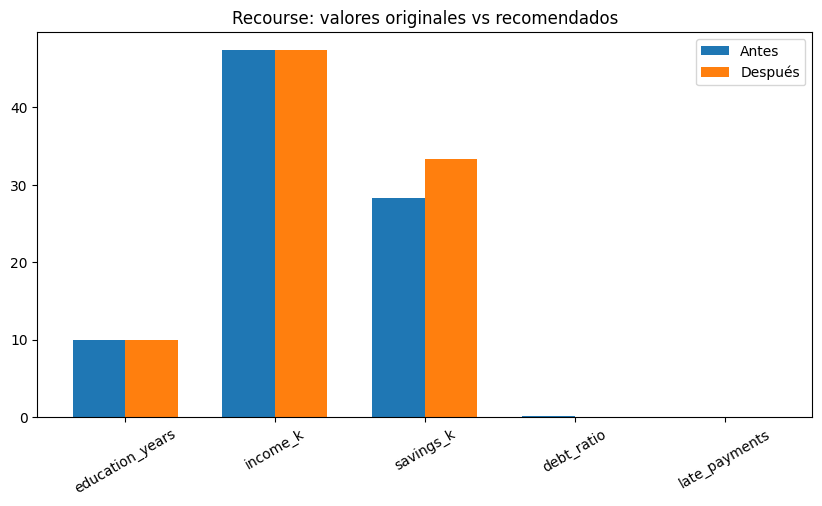

In [ ]:
# ============================================
# CELDA 11. GRÁFICO ANTES VS DESPUÉS
# ============================================

plot_features = list(actionable_features.keys())

before_vals = [person[f] for f in plot_features]
after_vals = [best_recourse["candidate"][f] for f in plot_features]

x = np.arange(len(plot_features))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, before_vals, width, label="Antes")
plt.bar(x + width/2, after_vals, width, label="Después")
plt.xticks(x, plot_features, rotation=30)
plt.title("Recourse: valores originales vs recomendados")
plt.legend()
plt.show()


## 12. Extensión temporal: el recourse puede vencerse

Esto conecta con la idea de *temporal recourse*: una recomendación útil hoy puede dejar de servir mañana.


In [ ]:
# ============================================
# CELDA 12. CHEQUEO TEMPORAL DEL RECOURSE
# ============================================

def temporal_check(candidate_row, model, feature_names,
                   income_drop=5,
                   debt_increase=0.08,
                   late_payment_increase=1):
    """
    Simula un escenario futuro adverso.
    """
    future = candidate_row.copy()

    future["income_k"] = max(10, future["income_k"] - income_drop)
    future["debt_ratio"] = min(0.95, future["debt_ratio"] + debt_increase)
    future["late_payments"] = min(8, future["late_payments"] + late_payment_increase)

    p_now = model.predict_proba(pd.DataFrame([candidate_row[feature_names]]))[0, 1]
    p_future = model.predict_proba(pd.DataFrame([future[feature_names]]))[0, 1]

    return round(float(p_now), 4), round(float(p_future), 4), future

p_now, p_future, future_case = temporal_check(
    best_recourse["candidate"],
    model,
    feature_names,
    income_drop=5,
    debt_increase=0.08,
    late_payment_increase=1
)

print("Probabilidad justo después del recourse:", p_now)
print("Probabilidad en un escenario futuro adverso:", p_future)

print("\nCaso futuro simulado:")
display(future_case.to_frame(name="future_value"))


Probabilidad justo después del recourse: 0.6313
Probabilidad en un escenario futuro adverso: 0.2172

Caso futuro simulado:


,future_value
age,43.000
education_years,10.000
income_k,42.400
savings_k,33.300
debt_ratio,0.130
late_payments,1.000
dependents,1.000


## Chequeo temporal del *recourse* e interpretación de los resultados

Esta sección introduce una idea muy importante en *algorithmic recourse*: una recomendación puede funcionar **hoy**, pero dejar de funcionar **mañana** si las condiciones cambian. Por eso, aquí no se pregunta solamente si el *recourse* logró cambiar la predicción en el momento actual, sino también si esa mejora es **estable en el tiempo**.

La lógica de esta celda es simular un escenario futuro adverso y verificar si la solución recomendada sigue siendo suficiente para mantener una predicción positiva.

### Qué hace la función `temporal_check`

La función `temporal_check` recibe como entrada:

- `candidate_row`: el caso ya modificado por el *recourse*,
- `model`: el modelo entrenado,
- `feature_names`: la lista de variables del modelo,
- y tres parámetros que representan un deterioro futuro:
  - `income_drop=5`
  - `debt_increase=0.08`
  - `late_payment_increase=1`

La función parte del caso recomendado y construye una nueva versión llamada `future`, que representa un posible escenario adverso en el futuro.

### Qué cambios se simulan

La simulación aplica tres modificaciones:

- `income_k` disminuye en 5 unidades.
- `debt_ratio` aumenta en 0.08.
- `late_payments` aumenta en 1 unidad.

Además, el código impone límites para evitar valores imposibles:

- el ingreso no puede bajar de 10,
- el ratio de deuda no puede superar 0.95,
- los pagos tardíos no pueden superar 8.

La idea conceptual es esta: después de aplicar el *recourse*, puede ocurrir que la situación de la persona empeore un poco. Entonces el notebook prueba si, aun con ese deterioro, la recomendación sigue sosteniendo una predicción favorable.

### Qué devuelve la función

La función devuelve tres elementos:

- `p_now`: la probabilidad del caso justo después del *recourse*,
- `p_future`: la probabilidad en el escenario futuro adverso,
- `future`: el nuevo caso simulado con los valores deteriorados.

En otras palabras, compara el presente corregido con un futuro menos favorable.

### Interpretación de los resultados obtenidos

Los resultados fueron:

- **Probabilidad justo después del recourse: `0.6313`**
- **Probabilidad en un escenario futuro adverso: `0.2172`**

Y el caso futuro simulado quedó así:

- `age = 43.000`
- `education_years = 10.000`
- `income_k = 42.400`
- `savings_k = 33.300`
- `debt_ratio = 0.130`
- `late_payments = 1.000`
- `dependents = 1.000`

### Lectura sustantiva del caso futuro

Comparado con el caso recomendado por el *recourse*, el escenario futuro mantiene iguales varias variables:

- `age` no cambia,
- `education_years` no cambia,
- `savings_k` no cambia,
- `dependents` no cambia.

Pero sí introduce tres deterioros:

- el ingreso baja de `47.400` a `42.400`,
- el ratio de deuda sube de `0.050` a `0.130`,
- los pagos tardíos suben de `0.000` a `1.000`.

Estos cambios son suficientes para que la probabilidad caiga de `0.6313` a `0.2172`.

### Qué significa esa caída de probabilidad

La caída es muy fuerte. La recomendación inicialmente dejaba al caso con una probabilidad relativamente cómoda por encima del umbral de 0.5. Sin embargo, bajo el shock simulado, la probabilidad cae muy por debajo del umbral.

Eso significa que la solución encontrada por el *recourse* era **efectiva en el presente**, pero **frágil ante cambios adversos posteriores**.

Dicho de otra manera:

- el *recourse* logró cambiar la predicción,
- pero no construyó un margen de seguridad lo suficientemente amplio como para resistir un deterioro moderado en las condiciones del caso.

### Interpretación metodológica

Esta sección ilustra la idea de **validez temporal del recourse**.

Una recomendación de *recourse* puede ser:

- **válida en el corto plazo**, porque cruza el umbral del modelo,
- pero **inestable en el mediano plazo**, porque pequeños cambios en el entorno la hacen colapsar.

Esto es importante porque, en aplicaciones reales, muchas variables no permanecen fijas. El ingreso puede fluctuar, el endeudamiento puede aumentar, y la conducta de pago puede empeorar. Si una solución solo funciona en una fotografía estática, entonces puede ser poco útil como recomendación práctica.

### Por qué esta sección es importante

Sin este chequeo temporal, uno podría concluir que el *recourse* fue exitoso simplemente porque cambió la predicción. Sin embargo, esta celda muestra que eso no basta. También es necesario preguntarse:

- ¿la recomendación sigue funcionando si el contexto cambia un poco?
- ¿o era apenas una solución que cruzaba el umbral por muy poco?

Por eso, esta parte del notebook amplía la evaluación del *recourse*: no solo analiza si la recomendación funciona, sino también **qué tan resistente es en el tiempo**.


## 13. Introducir plausibilidad y acción parcial

En la vida real, no basta con que un cambio sea matemáticamente suficiente. También debería ser:

- **plausible**,
- **consistente con el contexto**,
- y en algunos casos solo **parcialmente accionable**.

Aquí añadimos restricciones heurísticas, no causales, para ilustrar la idea:
- la educación no puede subir demasiado de golpe,
- una gran mejora en ahorros debería venir acompañada de alguna mejora en ingresos,
- una gran reducción de deuda no debería aparecer como magia de una noche.


In [ ]:
# ============================================
# CELDA 13. RESTRICCIONES DE PLAUSIBILIDAD
# ============================================

def is_plausible_candidate(original, candidate):
    income_delta = float(candidate["income_k"] - original["income_k"])
    savings_delta = float(candidate["savings_k"] - original["savings_k"])
    debt_improvement = float(original["debt_ratio"] - candidate["debt_ratio"])
    late_improvement = float(original["late_payments"] - candidate["late_payments"])
    education_delta = float(candidate["education_years"] - original["education_years"])

    rules = []

    # No asumir saltos educativos demasiado abruptos
    rules.append(education_delta <= 2)

    # Si aumentan mucho los ahorros, debería haber al menos una mejora modesta en ingresos
    rules.append(not (savings_delta > 15 and income_delta < 5))

    # Una fuerte reducción en deuda debería estar respaldada por ingresos o ahorros
    rules.append(not (debt_improvement > 0.10 and income_delta < 5 and savings_delta < 5))

    # Una fuerte mejora en pagos tardíos debería venir acompañada de alguna mejora financiera
    rules.append(not (late_improvement >= 2 and income_delta == 0 and savings_delta == 0))

    return all(rules)


def find_recourse_filtered(person_row, model, feature_names, actionable_features, plausibility_fn=None):
    value_grid = {
        f: build_candidate_values(float(person_row[f]), cfg)
        for f, cfg in actionable_features.items()
    }

    candidates = []

    for values in product(*[value_grid[f] for f in actionable_features.keys()]):
        candidate = person_row.copy()

        for f, v in zip(actionable_features.keys(), values):
            candidate[f] = v

        if plausibility_fn is not None and not plausibility_fn(person_row, candidate):
            continue

        x_candidate = pd.DataFrame([candidate[feature_names]])
        prob = model.predict_proba(x_candidate)[0, 1]
        pred = int(prob >= 0.5)

        if pred == 1:
            total_cost, cost_detail = recourse_cost(person_row, candidate, actionable_features)

            candidates.append({
                "prob_approve": round(float(prob), 4),
                "total_cost": total_cost,
                "candidate": candidate.copy(),
                "cost_detail": cost_detail
            })

    if len(candidates) == 0:
        return None, []

    candidates = sorted(candidates, key=lambda x: (x["total_cost"], -x["prob_approve"]))
    return candidates[0], candidates


plausible_recourse, plausible_candidates = find_recourse_filtered(
    person_row=person,
    model=model,
    feature_names=feature_names,
    actionable_features=actionable_features,
    plausibility_fn=is_plausible_candidate
)

print("Número de soluciones plausibles encontradas:", len(plausible_candidates))
print("\nMejor solución plausible:")
print(plausible_recourse)


Número de soluciones plausibles encontradas: 359

Mejor solución plausible:
{'prob_approve': 0.6313, 'total_cost': np.float64(2.0), 'candidate': age               43.000
education_years   10.000
income_k          47.400
savings_k         33.300
debt_ratio         0.050
late_payments      0.000
dependents         1.000
Name: 305, dtype: float64, 'cost_detail': {'education_years': np.float64(0.0), 'income_k': np.float64(0.0), 'savings_k': np.float64(0.8), 'debt_ratio': np.float64(1.2), 'late_payments': np.float64(0.0)}}


## Restricciones de plausibilidad y búsqueda de *recourse* filtrado

En esta sección se introduce una idea clave para hacer el *recourse* más realista: no basta con que una recomendación logre cambiar la predicción del modelo, también debería ser **plausible** desde el punto de vista sustantivo.

Hasta este punto, el notebook encontraba combinaciones de cambios que eran matemáticamente válidas y respetaban las reglas de *actionability*. Sin embargo, aun dentro de esas reglas, pueden aparecer soluciones poco creíbles en la práctica. Por ejemplo, podría encontrarse una combinación donde aumentan mucho los ahorros sin que haya ninguna mejora en ingresos, o una caída fuerte de deuda sin una explicación financiera razonable.

Por eso, esta celda añade un segundo filtro: además de ser **accionable**, una solución debe ser también **plausible**.

### Función `is_plausible_candidate`

La función `is_plausible_candidate(original, candidate)` compara el caso original con un caso candidato y evalúa si los cambios propuestos cumplen ciertas reglas heurísticas de plausibilidad.

Para hacerlo, primero calcula cinco diferencias:

- `income_delta`: cuánto aumenta el ingreso.
- `savings_delta`: cuánto aumentan los ahorros.
- `debt_improvement`: cuánto mejora el ratio de deuda.
- `late_improvement`: cuánto mejoran los pagos tardíos.
- `education_delta`: cuánto aumentan los años de educación.

Estas cantidades sirven para revisar si los cambios propuestos mantienen cierta coherencia.

### Reglas de plausibilidad

La función define una lista de reglas y luego exige que **todas** se cumplan.

#### 1. No asumir saltos educativos demasiado abruptos

Se impone que:

- `education_delta <= 2`

Esto significa que el número de años de educación no puede aumentar en más de dos unidades. La idea es evitar recomendaciones como “sume cuatro años de educación” si eso resulta poco verosímil en el horizonte temporal implícito del problema.

#### 2. Si aumentan mucho los ahorros, debería haber al menos una mejora modesta en ingresos

Se descarta cualquier candidato en el que:

- los ahorros aumenten más de 15,
- pero el ingreso aumente menos de 5.

La lógica es que un salto importante en ahorros sin ninguna mejora en ingresos puede ser poco creíble. No es imposible, pero el notebook lo trata como una señal de poca plausibilidad.

#### 3. Una fuerte reducción de deuda debería estar respaldada por ingresos o ahorros

Se descarta cualquier candidato en el que:

- la mejora en deuda sea mayor a 0.10,
- y al mismo tiempo no haya una mejora de al menos 5 en ingresos,
- ni una mejora de al menos 5 en ahorros.

La idea aquí es que una reducción fuerte de deuda no debería aparecer “de la nada”. Si la deuda mejora mucho, debería existir alguna mejora financiera que la respalde.

#### 4. Una fuerte mejora en pagos tardíos debería venir acompañada de alguna mejora financiera

Se descarta cualquier candidato en el que:

- los pagos tardíos mejoren en 2 o más unidades,
- pero no haya ningún aumento ni en ingresos ni en ahorros.

Esta regla intenta evitar soluciones donde la conducta de pago mejora mucho sin ningún cambio que haga esa mejora razonable.

### Resultado de `is_plausible_candidate`

La función devuelve `all(rules)`, es decir:

- `True` si todas las reglas se cumplen,
- `False` si al menos una falla.

Por tanto, esta función actúa como un filtro adicional que separa las soluciones simplemente posibles de las soluciones además plausibles.

### Función `find_recourse_filtered`

La función `find_recourse_filtered(...)` es una extensión de la función anterior de búsqueda de *recourse*. Su lógica general es la misma:

1. Construye la grilla de valores posibles para cada variable accionable.
2. Genera todas las combinaciones posibles.
3. Evalúa cada combinación con el modelo.
4. Conserva solo las que cambian la predicción a positiva.
5. Calcula el costo de cada solución.
6. Ordena las soluciones por costo y luego por probabilidad.

La diferencia importante es que ahora incluye este paso adicional:

- si existe una función de plausibilidad (`plausibility_fn`) y el candidato no la cumple, la combinación se descarta antes de ser evaluada por el modelo.

En otras palabras, el algoritmo ya no busca solo soluciones que funcionen, sino soluciones que funcionen **y además pasen el filtro de plausibilidad**.

### Ejecución del filtro de plausibilidad

En esta celda se llama a la función así:

- `person_row = person`
- `model = model`
- `feature_names = feature_names`
- `actionable_features = actionable_features`
- `plausibility_fn = is_plausible_candidate`

Eso significa que la búsqueda se hace sobre el mismo caso analizado antes, pero ahora imponiendo el conjunto de reglas heurísticas de plausibilidad.

### Interpretación de los resultados

El resultado mostrado fue:

- **Número de soluciones plausibles encontradas: `359`**
- y la mejor solución plausible fue:

  - `prob_approve = 0.6313`
  - `total_cost = 2.0`

  con el siguiente caso recomendado:

  - `age = 43.000`
  - `education_years = 10.000`
  - `income_k = 47.400`
  - `savings_k = 33.300`
  - `debt_ratio = 0.050`
  - `late_payments = 0.000`
  - `dependents = 1.000`

  y el siguiente detalle de costo:

  - `education_years = 0.0`
  - `income_k = 0.0`
  - `savings_k = 0.8`
  - `debt_ratio = 1.2`
  - `late_payments = 0.0`

### Qué significa que haya 359 soluciones plausibles

Antes del filtro de plausibilidad se habían encontrado más soluciones válidas. Ahora, después del filtro, ese conjunto se redujo a **359 soluciones plausibles**.

Esto significa que varias de las soluciones matemáticamente válidas fueron descartadas por no cumplir criterios razonables de coherencia.

La lectura metodológica es importante:

- el espacio de soluciones posibles se reduce,
- pero las soluciones que quedan son más defendibles desde el punto de vista sustantivo.

### Qué significa que la mejor solución plausible sea la misma

Lo más interesante del resultado es que, aunque el número total de soluciones se redujo, la **mejor solución plausible coincide con la mejor solución encontrada antes**.

Eso quiere decir que la recomendación de menor costo que ya habíamos identificado no solo era matemáticamente efectiva, sino también razonablemente plausible bajo las reglas definidas.

En este caso, el filtro de plausibilidad no cambió la mejor recomendación, pero sí eliminó muchas otras alternativas menos creíbles.

### Lectura sustantiva del resultado

La mejor solución plausible sigue consistiendo en:

- aumentar `savings_k` de `28.3` a `33.3`,
- reducir `debt_ratio` de `0.09` a `0.05`,
- sin modificar educación, ingreso, pagos tardíos, edad ni dependientes.

La probabilidad final se mantiene en `0.6313`, y el costo total sigue siendo `2.0`.

Esto sugiere que la recomendación encontrada tiene una doble fortaleza:

- funciona para cambiar la predicción,
- y además no viola las reglas heurísticas de plausibilidad impuestas.

## 14. Evaluación en lote sobre varios casos rechazados

Ahora pasamos de un solo caso a una pequeña **mini-población** de casos rechazados.

Esto nos permite responder preguntas como:
- ¿con qué frecuencia encontramos recourse?
- ¿qué tan costoso suele ser?
- ¿cuánto sube, en promedio, la probabilidad?
- ¿cuánto cambia el panorama cuando imponemos plausibilidad?


In [ ]:
# ============================================
# CELDA 14. EVALUACIÓN EN LOTE
# ============================================

def evaluate_recourse_batch(rejected_df, model, feature_names, actionable_features, plausibility_fn=None, max_cases=40):
    rows = []

    sample_df = rejected_df.head(max_cases).copy()

    for idx, row in sample_df.iterrows():
        person_row = row[feature_names].copy()
        base_prob = float(model.predict_proba(pd.DataFrame([person_row]))[0, 1])

        best, _ = find_recourse_filtered(
            person_row=person_row,
            model=model,
            feature_names=feature_names,
            actionable_features=actionable_features,
            plausibility_fn=plausibility_fn
        )

        result = {
            "index": idx,
            "base_prob": base_prob,
            "found_recourse": best is not None
        }

        if best is not None:
            result["new_prob"] = best["prob_approve"]
            result["prob_gain"] = best["prob_approve"] - base_prob
            result["total_cost"] = best["total_cost"]
            result["age"] = person_row["age"]
            result["dependents"] = person_row["dependents"]
        else:
            result["new_prob"] = np.nan
            result["prob_gain"] = np.nan
            result["total_cost"] = np.nan
            result["age"] = person_row["age"]
            result["dependents"] = person_row["dependents"]

        rows.append(result)

    return pd.DataFrame(rows)

batch_free = evaluate_recourse_batch(
    rejected_df=rejected,
    model=model,
    feature_names=feature_names,
    actionable_features=actionable_features,
    plausibility_fn=None,
    max_cases=40
)

batch_plausible = evaluate_recourse_batch(
    rejected_df=rejected,
    model=model,
    feature_names=feature_names,
    actionable_features=actionable_features,
    plausibility_fn=is_plausible_candidate,
    max_cases=40
)

summary_batch = pd.DataFrame([
    {
        "scenario": "Libre",
        "n_cases": len(batch_free),
        "success_rate": batch_free["found_recourse"].mean(),
        "avg_cost_successes": batch_free.loc[batch_free["found_recourse"], "total_cost"].mean(),
        "avg_prob_gain_successes": batch_free.loc[batch_free["found_recourse"], "prob_gain"].mean()
    },
    {
        "scenario": "Plausible",
        "n_cases": len(batch_plausible),
        "success_rate": batch_plausible["found_recourse"].mean(),
        "avg_cost_successes": batch_plausible.loc[batch_plausible["found_recourse"], "total_cost"].mean(),
        "avg_prob_gain_successes": batch_plausible.loc[batch_plausible["found_recourse"], "prob_gain"].mean()
    }
])

display(summary_batch)


KeyboardInterrupt: 

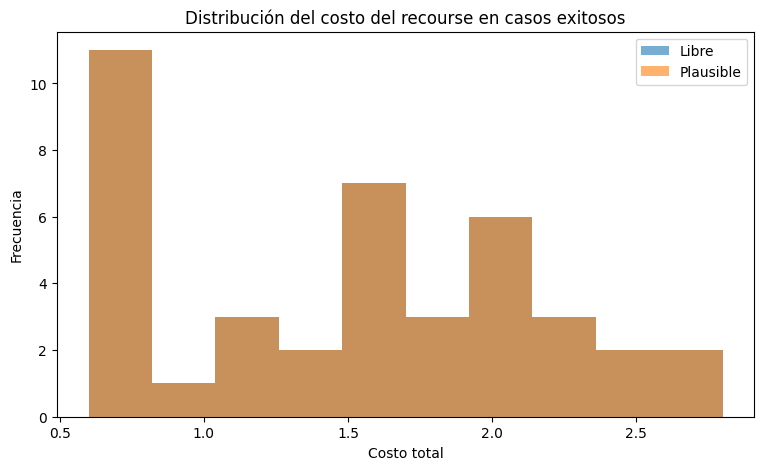

In [ ]:
# ============================================
# CELDA 15. VISUALIZAR COSTOS EN LOTE
# ============================================

plt.figure(figsize=(9, 5))
plt.hist(batch_free.loc[batch_free["found_recourse"], "total_cost"].dropna(), alpha=0.6, label="Libre")
plt.hist(batch_plausible.loc[batch_plausible["found_recourse"], "total_cost"].dropna(), alpha=0.6, label="Plausible")
plt.title("Distribución del costo del recourse en casos exitosos")
plt.xlabel("Costo total")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

def interpret_batch_results(summary_batch):
    free_row = summary_batch[summary_batch["scenario"] == "Libre"].iloc[0]
    plausible_row = summary_batch[summary_batch["scenario"] == "Plausible"].iloc[0]

    text = []
    text.append("### Interpretación de la evaluación en lote")
    text.append(f"- En el escenario libre, la tasa de éxito es **{free_row['success_rate']:.2%}**.")
    text.append(f"- En el escenario plausible, la tasa de éxito es **{plausible_row['success_rate']:.2%}**.")
    text.append(f"- El costo promedio entre los éxitos pasa de **{free_row['avg_cost_successes']:.3f}** a **{plausible_row['avg_cost_successes']:.3f}**.")
    text.append(f"- La ganancia promedio de probabilidad pasa de **{free_row['avg_prob_gain_successes']:.3f}** a **{plausible_row['avg_prob_gain_successes']:.3f}**.")
    text.append("- Si la plausibilidad reduce la tasa de éxito, eso es normal: muchas rutas baratas eran matemáticamente útiles, pero poco realistas.")
    text.append("- Si además aumenta el costo promedio, eso sugiere que las soluciones más creíbles suelen exigir esfuerzos mayores.")

interpret_batch_results(summary_batch)


## 16. Robustez temporal en lote

Una buena recomendación no solo debe funcionar **hoy**. También conviene preguntarse:

- ¿sigue funcionando si el contexto cambia un poco?
- ¿se mantiene la aprobación después de un shock razonable?
- ¿o era una solución demasiado frágil?

Aquí evaluamos la robustez temporal de los recourses plausibles.


In [ ]:
# ============================================
# CELDA 16. ROBUSTEZ TEMPORAL EN LOTE
# ============================================

def collect_successful_recourse_objects(rejected_df, model, feature_names, actionable_features, plausibility_fn=None, max_cases=40):
    rows = []
    sample_df = rejected_df.head(max_cases).copy()

    for idx, row in sample_df.iterrows():
        person_row = row[feature_names].copy()

        best, _ = find_recourse_filtered(
            person_row=person_row,
            model=model,
            feature_names=feature_names,
            actionable_features=actionable_features,
            plausibility_fn=plausibility_fn
        )

        if best is not None:
            rows.append({
                "index": idx,
                "person": person_row,
                "recourse": best["candidate"],
                "prob_after": best["prob_approve"],
                "cost": best["total_cost"]
            })

    return rows

successful_plausible = collect_successful_recourse_objects(
    rejected_df=rejected,
    model=model,
    feature_names=feature_names,
    actionable_features=actionable_features,
    plausibility_fn=is_plausible_candidate,
    max_cases=40
)

temporal_rows = []

for item in successful_plausible:
    p_now, p_future, future_case = temporal_check(
        item["recourse"],
        model,
        feature_names,
        income_drop=5,
        debt_increase=0.08,
        late_payment_increase=1
    )

    temporal_rows.append({
        "index": item["index"],
        "prob_after": p_now,
        "prob_future": p_future,
        "drop": p_now - p_future,
        "remains_approved": p_future >= 0.5,
        "cost": item["cost"]
    })

temporal_df = pd.DataFrame(temporal_rows)
display(temporal_df.head())

if len(temporal_df) > 0:
    temporal_summary = pd.DataFrame([{
        "n_successful_recourse": len(temporal_df),
        "share_remaining_approved": temporal_df["remains_approved"].mean(),
        "avg_probability_drop": temporal_df["drop"].mean()
    }])
else:
    temporal_summary = pd.DataFrame([{
        "n_successful_recourse": 0,
        "share_remaining_approved": np.nan,
        "avg_probability_drop": np.nan
    }])

display(temporal_summary)


,index,prob_after,prob_future,drop,remains_approved,cost
0,36,0.533,0.156,0.377,False,1.200
1,253,0.521,0.150,0.371,False,0.900
2,707,0.507,0.143,0.364,False,0.600
3,505,0.608,0.201,0.407,False,0.800
4,84,0.600,0.196,0.404,False,0.800


,n_successful_recourse,share_remaining_approved,avg_probability_drop
0,40,0.000,0.385


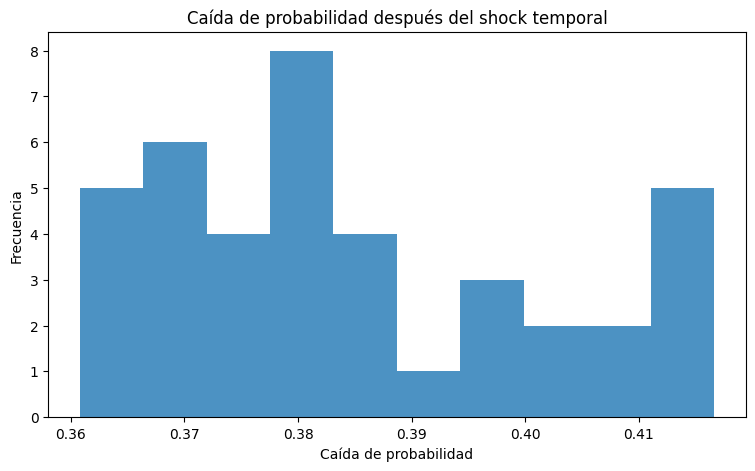

In [ ]:
# ============================================
# CELDA 17. INTERPRETAR ROBUSTEZ TEMPORAL
# ============================================

if len(temporal_df) > 0:
    plt.figure(figsize=(9, 5))
    plt.hist(temporal_df["drop"], alpha=0.8)
    plt.title("Caída de probabilidad después del shock temporal")
    plt.xlabel("Caída de probabilidad")
    plt.ylabel("Frecuencia")
    plt.show()

def interpret_temporal_results(temporal_summary):
    row = temporal_summary.iloc[0]

    text = []
    text.append("### Interpretación temporal")

    if row["n_successful_recourse"] == 0:
        text.append("- No hubo recourses plausibles exitosos para evaluar robustez temporal.")
    else:
        text.append(f"- Se evaluaron **{int(row['n_successful_recourse'])}** casos con recourse plausible exitoso.")
        text.append(f"- La proporción que se mantiene aprobada después del shock es **{row['share_remaining_approved']:.2%}**.")
        text.append(f"- La caída promedio de probabilidad es **{row['avg_probability_drop']:.3f}**.")
        text.append("- Si muchas recomendaciones dejan de funcionar tras un pequeño shock, el recourse es frágil.")
        text.append("- Si la mayoría sobrevive, eso sugiere que las recomendaciones no solo cruzan el umbral, sino que crean cierto margen de seguridad.")

interpret_temporal_results(temporal_summary)


# Instalar y correr DiCE sobre tu caso actual

In [ ]:
# ============================================
# CELDA 18. DICE SOBRE EL NOTEBOOK ACTUAL
# ============================================

!pip -q install dice-ml

import dice_ml

# 1. Crear la instancia a explicar
query_instance = pd.DataFrame([person[feature_names]])

# 2. Definir rangos permitidos a partir de tus reglas de actionability
permitted_range = {
    f: [cfg["min_value"], cfg["max_value"]]
    for f, cfg in actionable_features.items()
}

# 3. Definir el objeto de datos para DiCE
# Como todas tus variables son numéricas, las tratamos como continuas
data_dice = dice_ml.Data(
    dataframe=df.copy(),
    continuous_features=feature_names,
    outcome_name="approved"
)

# 4. Envolver tu modelo sklearn ya entrenado
model_dice = dice_ml.Model(
    model=model,
    backend="sklearn"
)

# 5. Crear el generador de contrafactuales
# Puedes probar "random" o "genetic"; aquí usamos "genetic"
# porque suele dar soluciones más cuidadas
exp = dice_ml.Dice(
    data_dice,
    model_dice,
    method="genetic"
)

# 6. Generar contrafactuales
dice_result = exp.generate_counterfactuals(
    query_instances=query_instance,
    total_CFs=4,
    desired_class="opposite",
    features_to_vary=list(actionable_features.keys()),
    permitted_range=permitted_range
)

# 7. Visualizar solo los cambios
dice_result.visualize_as_dataframe(show_only_changes=True)

# 8. Extraer DataFrame final para usarlo después
dice_df = dice_result.cf_examples_list[0].final_cfs_df.copy()

print("Contrafactuales generados por DiCE:")
display(dice_df)

100%|██████████| 1/1 [00:00<00:00,  7.44it/s]

Query instance (original outcome : 0)


,age,education_years,income_k,savings_k,debt_ratio,late_payments,dependents,approved
0,43.000,10.000,47.400,28.300,0.090,0.000,1.000,0



Diverse Counterfactual set (new outcome: 1)


,age,education_years,income_k,savings_k,debt_ratio,late_payments,dependents,approved
0,-,-,54.7,33.8,0.12,-,-,1.0
0,-,-,59.4,35.3,0.12,-,-,1.0
0,-,-,52.8,34.7,0.04,-,-,1.0
0,-,-,55.2,34.7,0.04,-,-,1.0


Contrafactuales generados por DiCE:


,age,education_years,income_k,savings_k,debt_ratio,late_payments,dependents,approved
0,43.000,10.000,54.700,33.800,0.120,0.000,1.000,1
0,43.000,10.000,59.400,35.300,0.120,0.000,1.000,1
0,43.000,10.000,52.800,34.700,0.040,0.000,1.000,1
0,43.000,10.000,55.200,34.700,0.040,0.000,1.000,1


# Calcular costo de los contrafactuales de DiCE con tu misma métrica

In [ ]:
# ============================================
# CELDA 19. EVALUAR LOS CF DE DICE CON TU MÉTRICA
# ============================================

dice_eval_rows = []

if dice_df is not None and len(dice_df) > 0:
    for i, (_, row) in enumerate(dice_df.iterrows(), start=1):
        candidate = row[feature_names].copy()

        # Probabilidad con tu modelo original
        prob_candidate = float(model.predict_proba(pd.DataFrame([candidate]))[0, 1])

        # Costo usando tu función manual
        total_cost, cost_detail = recourse_cost(
            original=person,
            candidate=candidate,
            actionable_features=actionable_features
        )

        # Resumen de cambios
        changed_features = [
            f for f in feature_names
            if abs(float(candidate[f] - person[f])) > 1e-9
        ]

        dice_eval_rows.append({
            "cf_rank": i,
            "prob_approve": round(prob_candidate, 4),
            "total_cost_manual_metric": float(total_cost),
            "n_changed_features": len(changed_features),
            "changed_features": ", ".join(changed_features),
            "cost_detail": str(cost_detail)
        })

    dice_eval_df = pd.DataFrame(dice_eval_rows)
    display(dice_eval_df)
else:
    print("DiCE no devolvió contrafactuales.")

,cf_rank,prob_approve,total_cost_manual_metric,n_changed_features,changed_features,cost_detail
0,1,0.752,2.340,3,"income_k, savings_k, debt_ratio","{'education_years': np.float64(0.0), 'income_k..."
1,2,0.863,3.520,3,"income_k, savings_k, debt_ratio","{'education_years': np.float64(0.0), 'income_k..."
2,3,0.800,3.604,3,"income_k, savings_k, debt_ratio","{'education_years': np.float64(0.0), 'income_k..."
3,4,0.841,4.084,3,"income_k, savings_k, debt_ratio","{'education_years': np.float64(0.0), 'income_k..."


# Comparar el mejor recourse manual vs el mejor contrafactual de DiCE

In [ ]:
# ============================================
# CELDA 20. COMPARACIÓN MANUAL VS DICE
# ============================================

comparison_rows = []

# Mejor solución manual
if best_recourse is not None:
    comparison_rows.append({
        "method": "Manual grid search",
        "prob_approve": best_recourse["prob_approve"],
        "total_cost": float(best_recourse["total_cost"]),
        "n_changed_features": int(sum(
            abs(float(best_recourse["candidate"][f] - person[f])) > 1e-9
            for f in feature_names
        ))
    })

# Mejor solución de DiCE según tu métrica de costo
if "dice_eval_df" in globals() and len(dice_eval_df) > 0:
    best_dice_idx = dice_eval_df["total_cost_manual_metric"].idxmin()
    best_dice_row = dice_eval_df.loc[best_dice_idx]

    comparison_rows.append({
        "method": "DiCE",
        "prob_approve": best_dice_row["prob_approve"],
        "total_cost": best_dice_row["total_cost_manual_metric"],
        "n_changed_features": best_dice_row["n_changed_features"]
    })

comparison_methods_df = pd.DataFrame(comparison_rows)
display(comparison_methods_df)

,method,prob_approve,total_cost,n_changed_features
0,Manual grid search,0.631,2.000,2
1,DiCE,0.752,2.340,3


# Ver exactamente qué cambia en el mejor contrafactual de DiCE

In [ ]:
# ============================================
# CELDA 21. RESUMEN HUMANO DEL MEJOR CF DE DICE
# ============================================

if "dice_eval_df" in globals() and len(dice_eval_df) > 0:
    best_dice_idx = dice_eval_df["total_cost_manual_metric"].idxmin()
    best_dice_candidate = dice_df.iloc[best_dice_idx][feature_names].copy()

    summary_rows_dice = []
    for f in feature_names:
        summary_rows_dice.append({
            "feature": f,
            "original": person[f],
            "dice_recommended": best_dice_candidate[f],
            "delta": round(float(best_dice_candidate[f] - person[f]), 3)
        })

    summary_dice_df = pd.DataFrame(summary_rows_dice)
    display(summary_dice_df)

    print("Probabilidad original:",
          round(float(model.predict_proba(pd.DataFrame([person]))[0, 1]), 4))
    print("Probabilidad con mejor CF de DiCE:",
          round(float(model.predict_proba(pd.DataFrame([best_dice_candidate]))[0, 1]), 4))
else:
    print("No hay contrafactuales de DiCE para resumir.")

,feature,original,dice_recommended,delta
0,age,43.000,43.000,0.000
1,education_years,10.000,10.000,0.000
2,income_k,47.400,54.700,7.300
3,savings_k,28.300,33.800,5.500
4,debt_ratio,0.090,0.120,0.030
5,late_payments,0.000,0.000,0.000
6,dependents,1.000,1.000,0.000


Probabilidad original: 0.4347
Probabilidad con mejor CF de DiCE: 0.7516
